In [8]:
import torch
import torch.nn as nn
import numpy as np

In [2]:
loss_fn=nn.TripletMarginLoss()

In [3]:
a=torch.randn(100,5,requires_grad=True)#待测
p=torch.randn(100,5,requires_grad=True)#正例
n=torch.randn(100,5,requires_grad=True)#反例

In [4]:
loss_value=loss_fn(a,p,n)
print(loss_value)

tensor(1.1329, grad_fn=<MeanBackward0>)


In [9]:
#椒盐噪声
def pepper_salt(img,percentage):
    noise_img=img.copy()
    #按比例计算噪点个数
    noise_num=int(percentage*img.shape[0]*img.shape[1])
    for i in range(noise_num):
        #随机生成噪点坐标
        randx=np.random.randint(0,img.shape[0]-1)
        randy=np.random.randint(0,img.shape[1]-1)
        #均匀生成黑白噪点
        if np.random.rand()<0.5:
            noise_img[randx,randy]=0
        else:
            noise_img[randx,randy]=255
    return noise_img

In [11]:
from PIL import Image#图像加载
import matplotlib.pyplot as plt
import torchvision.transforms as transforms#图形预处理
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [13]:
image_path='Apple.jpg'
img=Image.open(image_path)

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()#转化为浮点数 并且归一化
    ])
img_tensor=transform(img)
print(img_tensor.shape)

img_ndarray=img_tensor.permute(1,2,0).numpy()
print(img_ndarray.shape)

torch.Size([3, 256, 256])
(256, 256, 3)


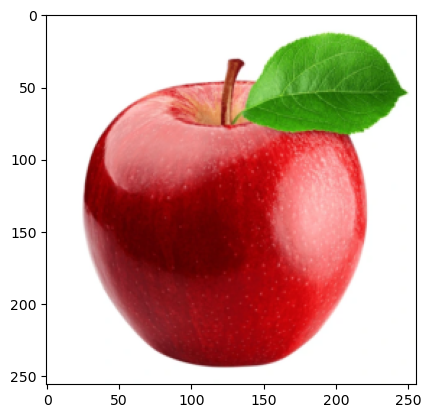

In [14]:
plt.imshow(img_ndarray)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


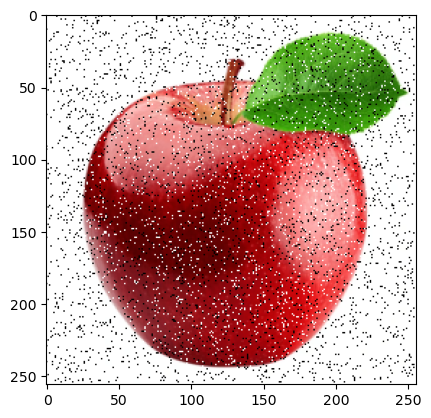

In [16]:
#加入椒盐噪声
plt.imshow(pepper_salt(img_ndarray,0.1))
plt.show()